In [60]:
# load all the libraries

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
df = pd.read_csv("/content/HR Employee Attrition .csv")

In [63]:
df

,Sr. No,Age,Age Group,Attrition,Attrition Count,Attrition vs Non-Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,41,41-50,Yes,1,Attrition,Travel_Rarely,1102,Sales,1,...,1,80,0,8,0,1,6,4,0,5
1,2,49,41-50,No,0,Non-Attrition,Travel_Frequently,279,Research & Development,8,...,4,80,1,10,3,3,10,7,1,7
2,3,37,31-40,Yes,1,Attrition,Travel_Rarely,1373,Research & Development,2,...,2,80,0,7,3,3,0,0,0,0
3,4,33,31-40,No,0,Non-Attrition,Travel_Frequently,1392,Research & Development,3,...,3,80,0,8,3,3,8,7,3,0
4,5,27,18-30,No,0,Non-Attrition,Travel_Rarely,591,Research & Development,2,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1466,36,31-40,No,0,Non-Attrition,Travel_Frequently,884,Research & Development,23,...,3,80,1,17,3,3,5,2,0,3
1466,1467,39,31-40,No,0,Non-Attrition,Travel_Rarely,613,Research & Development,6,...,1,80,1,9,5,3,7,7,1,7
1467,1468,27,18-30,No,0,Non-Attrition,Travel_Rarely,155,Research & Development,4,...,2,80,1,6,0,3,6,2,0,3
1468,1469,49,41-50,No,0,Non-Attrition,Travel_Frequently,1023,Sales,2,...,4,80,0,17,3,2,9,6,0,8


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Sr. No                      1470 non-null   int64 
 1   Age                         1470 non-null   int64 
 2   Age Group                   1470 non-null   object
 3   Attrition                   1470 non-null   object
 4   Attrition Count             1470 non-null   int64 
 5   Attrition vs Non-Attrition  1470 non-null   object
 6   BusinessTravel              1470 non-null   object
 7   DailyRate                   1470 non-null   int64 
 8   Department                  1470 non-null   object
 9   DistanceFromHome            1470 non-null   int64 
 10  Education                   1470 non-null   int64 
 11  EducationField              1470 non-null   object
 12  EmployeeCount               1470 non-null   int64 
 13  EmployeeNumber              1470 non-null   int6

In [65]:
df.columns

Index(['Sr. No', 'Age', 'Age Group', 'Attrition', 'Attrition Count',
       'Attrition vs Non-Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [66]:
#1. What are the overall employee attrition rate?

In [67]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


Text(0.5, 1.0, 'Attrition Count')

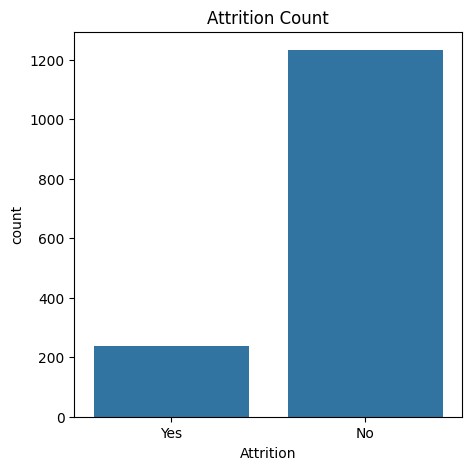

In [68]:
plt.figure(figsize=(5,5))
sns.countplot(x='Attrition',data=df)
plt.title('Attrition Count')

In [69]:
#2. How does attrition vary across departments?

In [70]:
df.groupby('Department')['Attrition'].value_counts().unstack()

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


([0, 1, 2],
 [Text(0, 0, 'Sales'),
  Text(1, 0, 'Research & Development'),
  Text(2, 0, 'Human Resources')])

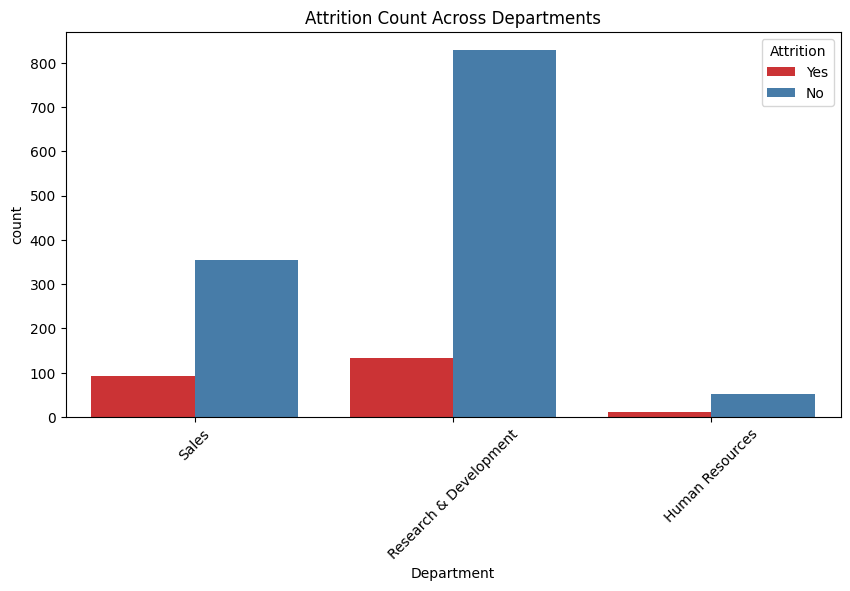

In [71]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Department',hue='Attrition',palette='Set1')
plt.title('Attrition Count Across Departments')
plt.xticks(rotation=45)

In [72]:
#3. Which job roles have the highest attrition?

In [73]:
df['JobRole'].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Sales Executive'),
  Text(1, 0, 'Research Scientist'),
  Text(2, 0, 'Laboratory Technician'),
  Text(3, 0, 'Manufacturing Director'),
  Text(4, 0, 'Healthcare Representative'),
  Text(5, 0, 'Manager'),
  Text(6, 0, 'Sales Representative'),
  Text(7, 0, 'Research Director'),
  Text(8, 0, 'Human Resources')])

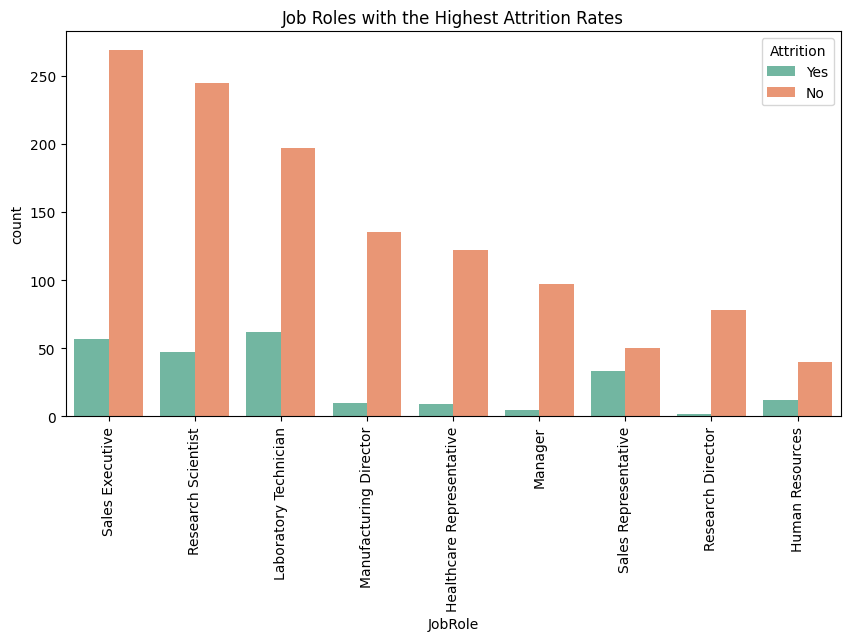

In [74]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='JobRole',hue='Attrition',palette='Set2')
plt.title("Job Roles with the Highest Attrition Rates")
plt.xticks(rotation=90)

In [75]:
#4. How does attrition change across different age groups?

In [76]:
df.groupby('Age Group')['Attrition'].value_counts().unstack().reset_index()

Attrition,Age Group,No,Yes
0,18-30,286,100
1,31-40,534,85
2,41-50,288,34
3,51-60,125,18


Text(0.5, 1.0, 'Attrition Count Across Age Groups')

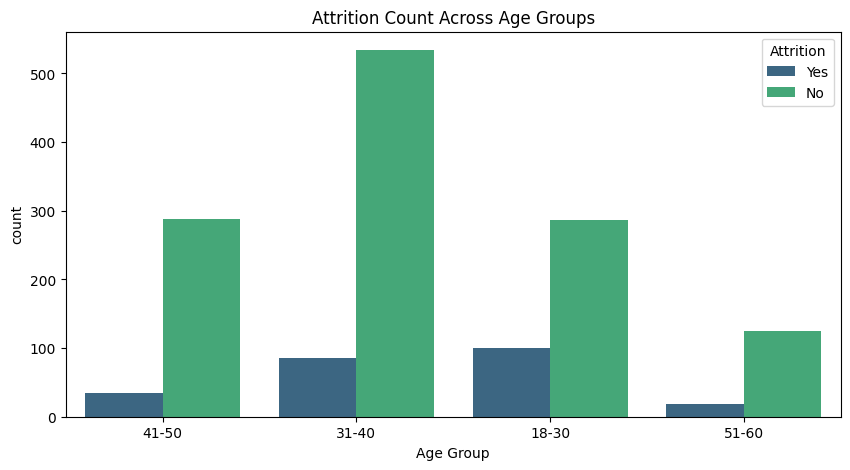

In [77]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Age Group',hue='Attrition',palette='viridis')
plt.title('Attrition Count Across Age Groups')


In [78]:
#5. Is there a difference in attrition between male and female employees?

In [79]:
df.groupby('Gender')['Attrition'].value_counts().unstack()

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


Text(0.5, 1.0, 'Attrition Count Across Gender')

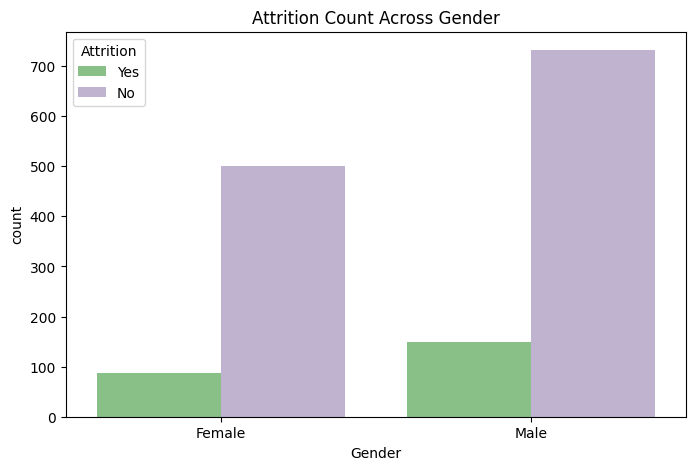

In [80]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender',hue='Attrition',palette='Accent')
plt.title('Attrition Count Across Gender')

In [81]:
#6. How does job satisfaction impact employee attrition?

In [82]:
df.groupby('JobSatisfaction')['Attrition'].value_counts().unstack()

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


Text(0.5, 1.0, 'Attrition Count Across Job Satisfaction')

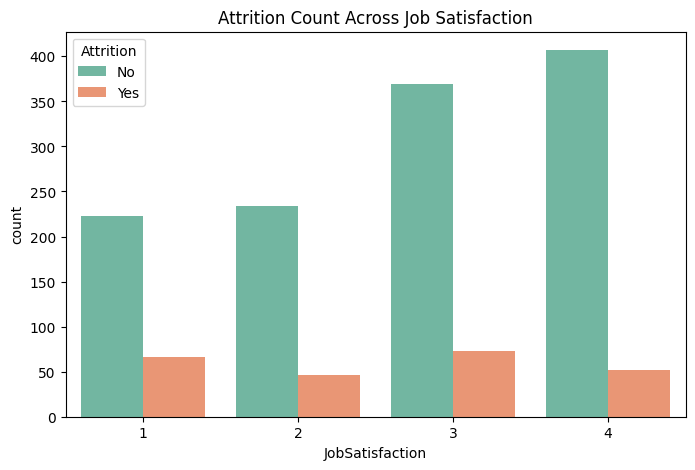

In [83]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='JobSatisfaction',hue='Attrition',palette='Set2')
plt.title('Attrition Count Across Job Satisfaction')

In [84]:
#7. What is the relationship between work-life balance and attrition?

In [85]:
df.groupby('WorkLifeBalance')['Attrition'].value_counts().unstack()

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


Text(0.5, 1.0, 'Relationship between WorkLifeBalance anf Attrition')

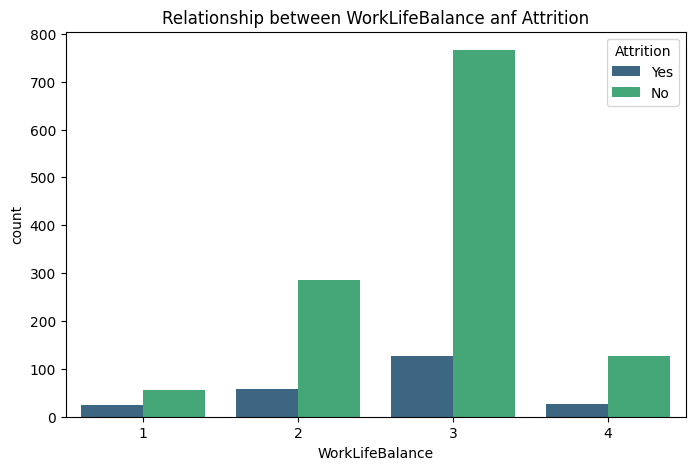

In [86]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='WorkLifeBalance',hue='Attrition',palette='viridis')
plt.title('Relationship between WorkLifeBalance anf Attrition')

In [87]:
#8. Does environment satisfaction influence attrition rates?

In [88]:
df.groupby('EnvironmentSatisfaction')['Attrition'].value_counts().unstack()

Attrition,No,Yes
EnvironmentSatisfaction,,
1,212,72
2,244,43
3,391,62
4,386,60


In [89]:
df.groupby('EnvironmentSatisfaction')['Attrition'].value_counts(normalize=True).unstack()*100

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


Text(0.5, 1.0, 'environmentSatisfaction Influence Attrition')

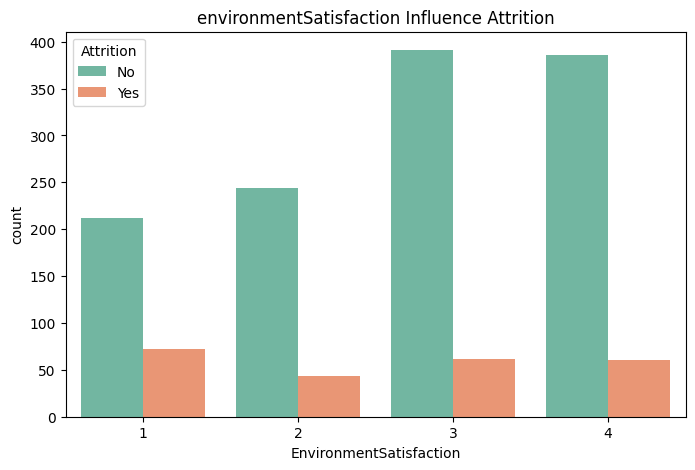

In [90]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='EnvironmentSatisfaction',hue='Attrition',palette='Set2')
plt.title('environmentSatisfaction Influence Attrition')

In [91]:
#9. How does job involvement affect employee attrition?

In [92]:
df.groupby('JobInvolvement')['Attrition'].value_counts().unstack().reset_index()

Attrition,JobInvolvement,No,Yes
0,1,55,28
1,2,304,71
2,3,743,125
3,4,131,13


<Axes: xlabel='JobInvolvement', ylabel='count'>

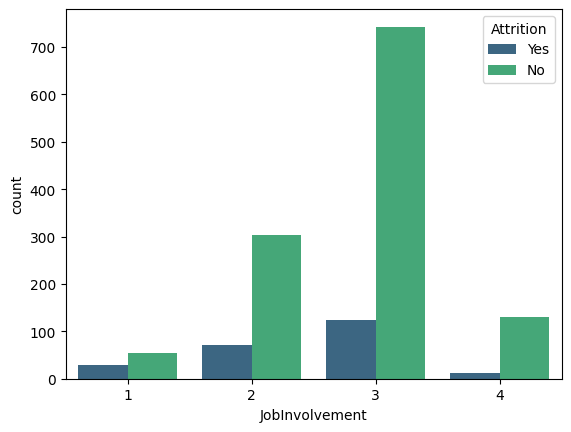

In [93]:
sns.countplot(data=df, x='JobInvolvement',hue='Attrition',palette='viridis')

In [94]:
#10. Which satisfaction factor has the strongest correlation with attrition?

In [95]:
df.groupby('JobSatisfaction')['Attrition'].value_counts().unstack().reset_index()

Attrition,JobSatisfaction,No,Yes
0,1,223,66
1,2,234,46
2,3,369,73
3,4,407,52


<Axes: xlabel='JobSatisfaction', ylabel='count'>

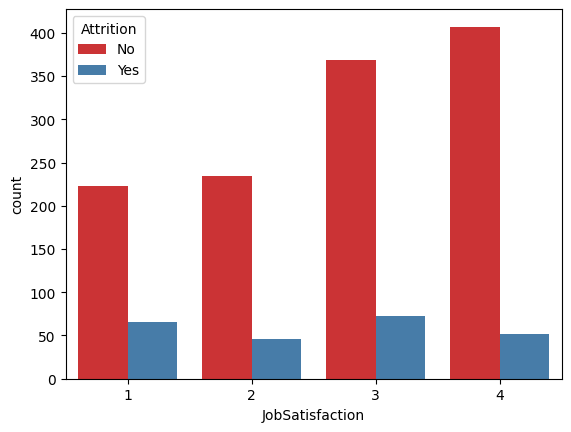

In [96]:
sns.countplot(data=df, x='JobSatisfaction',hue='Attrition',palette='Set1')

In [97]:
#11. Is there a significant difference in average monthly income between
# attrition nd non-attrition employees?

In [98]:
df1 = df.groupby('Attrition')['MonthlyIncome'].mean().reset_index()

In [99]:
df1

,Attrition,MonthlyIncome
0,No,6832.739659
1,Yes,4787.092827


/tmp/ipython-input-1415627384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df1, x='MonthlyIncome',y='Attrition',palette='viridis')


<Axes: xlabel='MonthlyIncome', ylabel='Attrition'>

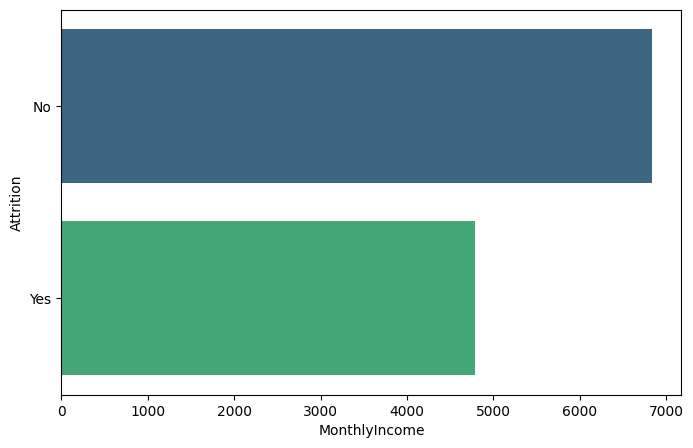

In [100]:
plt.figure(figsize=(8,5))
sns.barplot(data=df1, x='MonthlyIncome',y='Attrition',palette='viridis')

In [101]:
#12. How does education level impact attrition and average income?

Impact of Education Level on Attrition Rate and Average Monthy Income:
   Education  Attrition_Rate
0          1        0.182353
1          2        0.156028
2          3        0.173077
3          4        0.145729
4          5        0.104167


/tmp/ipython-input-390967275.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=education_impact, x='Education',y='Attrition_Rate',palette='viridis')
/tmp/ipython-input-390967275.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Education',y='MonthlyIncome',palette='viridis')


Text(0.5, 1.0, 'Average Monthly Income by Education Level')

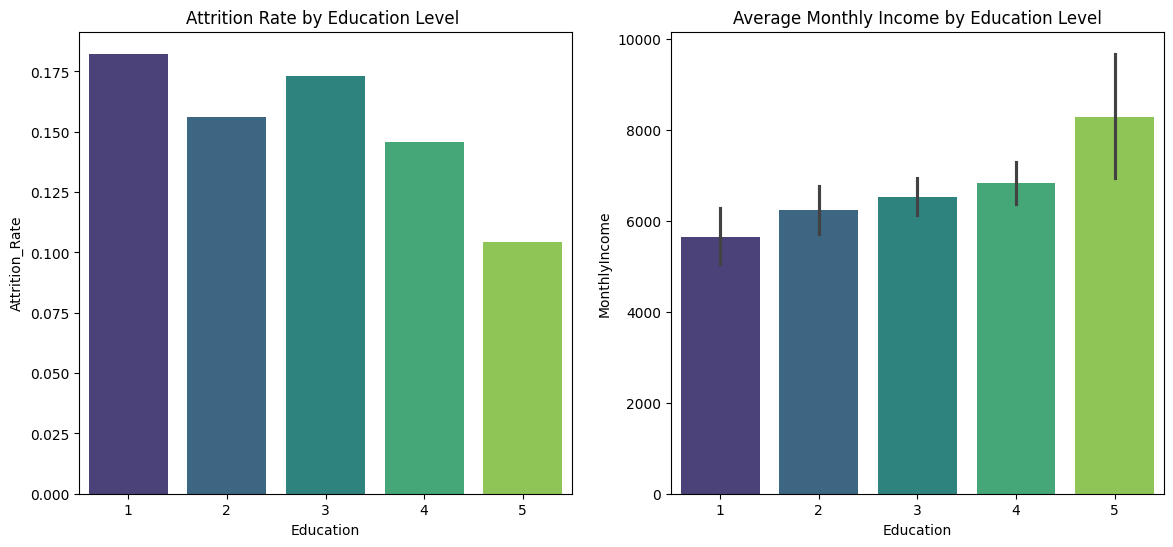

In [121]:
df['Attrition_Numerical'] = df['Attrition'].map({'Yes':1,'No':0})

education_impact = df.groupby('Education')['Attrition_Numerical'].mean().reset_index()
education_impact = education_impact.rename(columns={'Attrition_Numerical':'Attrition_Rate'})

print("Impact of Education Level on Attrition Rate and Average Monthy Income:")
print(education_impact)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.barplot(data=education_impact, x='Education',y='Attrition_Rate',palette='viridis')
plt.title('Attrition Rate by Education Level ')


plt.subplot(1,2,2)
sns.barplot(data=df, x='Education',y='MonthlyIncome',palette='viridis')
plt.title('Average Monthly Income by Education Level')

In [103]:
#13. Are high-performing employees more likely to leave the organization?

In [122]:
df.groupby('PerformanceRating')['Attrition'].value_counts().unstack()

Attrition,No,Yes
PerformanceRating,,
3,1044,200
4,189,37


<Axes: xlabel='PerformanceRating', ylabel='count'>

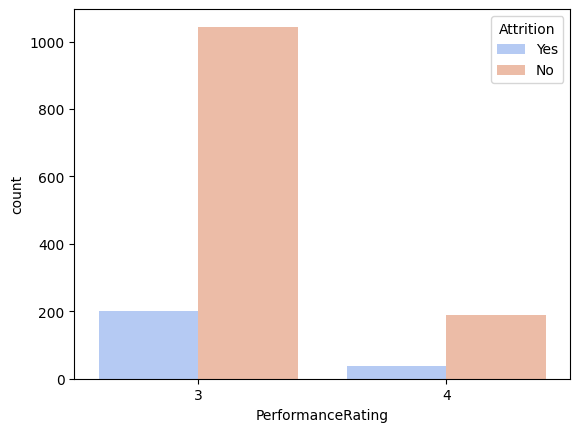

In [124]:
sns.countplot(data=df, x='PerformanceRating',hue='Attrition',palette='coolwarm')

In [104]:
#14. How does years at company influence attrition trends?

Attrition Rates by Years at Company:
    YearsAtCompany  Attrition_Rate
0                0        0.363636
1                1        0.345029
2                2        0.212598
3                3        0.156250
4                4        0.172727
5                5        0.107143
6                6        0.118421
7                7        0.122222
8                8        0.112500
9                9        0.097561
10              10        0.150000
11              11        0.062500
12              12        0.000000
13              13        0.083333
14              14        0.111111
15              15        0.050000
16              16        0.083333
17              17        0.111111
18              18        0.076923
19              19        0.090909
20              20        0.037037
21              21        0.071429
22              22        0.066667
23              23        0.500000
24              24        0.166667
25              25        0.000000
26              26

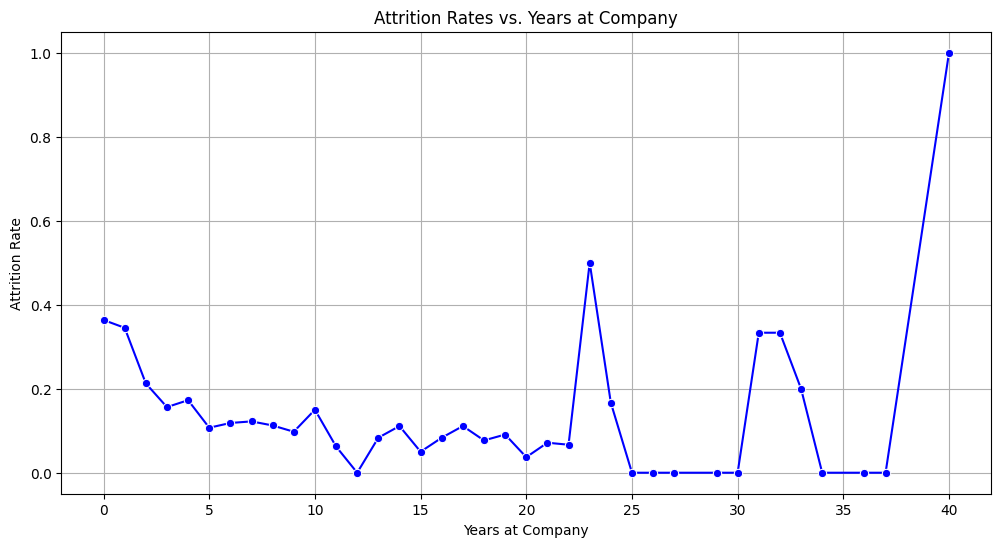

In [129]:
attrition_by_years = df.groupby('YearsAtCompany')['Attrition_Numerical'].mean().reset_index()
attrition_by_years = attrition_by_years.rename(columns={'Attrition_Numerical':'Attrition_Rate'})
print("Attrition Rates by Years at Company:")
print(attrition_by_years)

plt.figure(figsize=(12,6))
sns.lineplot(data=attrition_by_years, x='YearsAtCompany',y='Attrition_Rate',marker='o',color='blue')
plt.title('Attrition Rates vs. Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate')
plt.grid(True)
plt.show()

In [105]:
df.columns

Index(['Sr. No', 'Age', 'Age Group', 'Attrition', 'Attrition Count',
       'Attrition vs Non-Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [106]:
df

,Sr. No,Age,Age Group,Attrition,Attrition Count,Attrition vs Non-Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,41,41-50,Yes,1,Attrition,Travel_Rarely,1102,Sales,1,...,1,80,0,8,0,1,6,4,0,5
1,2,49,41-50,No,0,Non-Attrition,Travel_Frequently,279,Research & Development,8,...,4,80,1,10,3,3,10,7,1,7
2,3,37,31-40,Yes,1,Attrition,Travel_Rarely,1373,Research & Development,2,...,2,80,0,7,3,3,0,0,0,0
3,4,33,31-40,No,0,Non-Attrition,Travel_Frequently,1392,Research & Development,3,...,3,80,0,8,3,3,8,7,3,0
4,5,27,18-30,No,0,Non-Attrition,Travel_Rarely,591,Research & Development,2,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1466,36,31-40,No,0,Non-Attrition,Travel_Frequently,884,Research & Development,23,...,3,80,1,17,3,3,5,2,0,3
1466,1467,39,31-40,No,0,Non-Attrition,Travel_Rarely,613,Research & Development,6,...,1,80,1,9,5,3,7,7,1,7
1467,1468,27,18-30,No,0,Non-Attrition,Travel_Rarely,155,Research & Development,4,...,2,80,1,6,0,3,6,2,0,3
1468,1469,49,41-50,No,0,Non-Attrition,Travel_Frequently,1023,Sales,2,...,4,80,0,17,3,2,9,6,0,8


In [107]:
#15. Does time since last promotion affect attrition?

Attrition Rates by Years Since Last Promotion:
    YearsSinceLastPromotion  Attrition_Rate
0                         0        0.189329
1                         1        0.137255
2                         2        0.169811
3                         3        0.173077
4                         4        0.081967
5                         5        0.044444
6                         6        0.187500
7                         7        0.210526
8                         8        0.000000
9                         9        0.235294
10                       10        0.166667
11                       11        0.083333
12                       12        0.000000
13                       13        0.200000
14                       14        0.111111
15                       15        0.230769


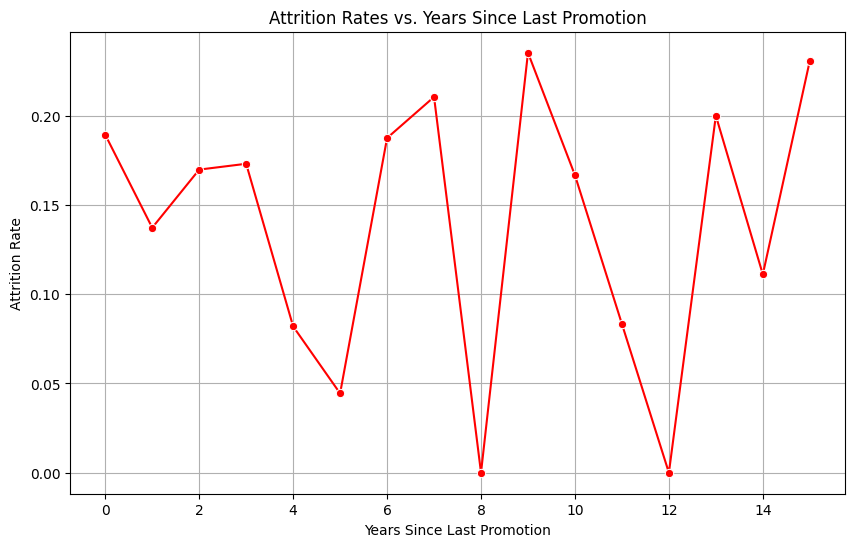

In [133]:
attrition_by_promotion = df.groupby('YearsSinceLastPromotion')['Attrition_Numerical'].mean().reset_index()
attrition_by_promotion = attrition_by_promotion.rename(columns={'Attrition_Numerical':'Attrition_Rate'})
print("Attrition Rates by Years Since Last Promotion:")
print(attrition_by_promotion)

plt.figure(figsize=(10,6))
sns.lineplot(data=attrition_by_promotion, x='YearsSinceLastPromotion',y='Attrition_Rate', marker='o',color='red')
plt.title('Attrition Rates vs. Years Since Last Promotion')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate')
plt.grid(True)
plt.show()

In [108]:
#16. How does distance from home impact attrition across job roles?

In [109]:
#17. Which job roles experience high attrition despite higher salaries?

In [110]:
#18. Does overtime work increase the likelihood of attrition?

In [111]:
#19. What combination of factors leads to the highest attrition risk?

In [112]:
#20. Who are the top high-risk employees most likely to leave the organization?